# Laboratory Task: Image Classification Using Pre-trained Models

**Name:** Clark James Tagalog &nbsp;·&nbsp; **Program:** BS Data Science (4th year)

---

### Goal of this notebook

Take a small, hand-curated image dataset that the models have **never seen**, and check how well five
ImageNet-pretrained models from `torchvision.models` recognise it **without any retraining**
(pure inference / "zero-shot transfer" through the ImageNet label space).

### Road map

| # | Section | What happens |
|---|---------|--------------|
| 1 | Setup | Libraries, reproducibility, plotting style |
| 2 | Dataset curation | Where the images come from, how they were chosen, folder structure |
| 3 | Mapping our labels to ImageNet | Why a pretrained model can even predict *our* classes |
| 4 | Custom `Dataset` class | Loading images + labels from the `dataset/<class_id>/` folders |
| 5 | Pre-processing | What each model expects as input (size, normalisation) |
| 6 | `DataLoader`s | Batching the dataset for evaluation |
| 7 | The five models | Architectures and their size / cost |
| 8 | Inference & evaluation | Accuracy, precision, recall, F1 under two protocols |
| 9 | Comparison & visualisations | Tables, bar charts, confusion matrices, error analysis |
| 10 | Input-requirement experiment | What happens when we feed the "wrong" input size / no normalisation |
| 11 | Analysis | Why the models differ |
| 12 | Conclusion | Summary of findings |

## 1. Setup

I import everything first. A fixed random seed is set since it keeps the bootstrap confidence intervals (Section 9) reproducible.

> **Note:** the pretrained weights are downloaded automatically by `torchvision` the first time each model is
> created (stored in `~/.cache/torch/hub/checkpoints`). Everything here runs fine on a CPU; a GPU just makes it faster.

In [1]:
import os, re, time, random, platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.precision", 3)

print(f"Python      : {platform.python_version()}")
print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"Device      : {DEVICE}  (CPU threads: {torch.get_num_threads()})")

Python      : 3.11.15
PyTorch     : 2.14.0+cu130
torchvision : 0.29.0+cu130
Device      : cpu  (CPU threads: 2)


**Plot style.** One consistent colour per model is used in every chart (so "orange" always means the same model),
with a light, low-contrast grid so the data stands out. The palette was checked for colour-blind separation;
because a few of the lighter colours have low contrast on white, every bar also carries a printed value label.

In [2]:
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
MODEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]   # fixed order, one per model
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.dpi": 110, "font.size": 10,
})

## 2. Dataset curation

### 2.1 Choosing the classes — the thought process

The task asks us to evaluate *pretrained* models **without fine-tuning**. A model trained on ImageNet-1k can only
output one of its 1,000 ImageNet classes, so my first design decision is:

> **Every class in my custom dataset must correspond to an existing ImageNet class**, otherwise no amount of
> "intelligence" in the model can produce the right answer and the evaluation would be meaningless.

Other requirements I set for myself:

1. **Visually diverse categories** — an instrument, an electronic device, a food, a marine animal and an everyday object —
   so the comparison is not dominated by one type of image.
2. **Images that are *not* from ImageNet itself.** If I tested on ImageNet photos, the models may have *trained* on those
   exact pictures, and the scores would be inflated (data leakage). I therefore took photos from a **different dataset**.
3. **Balanced classes** (same number of images per class) so that accuracy is not biased toward a large class.

### 2.2 Source of the images

The images were downloaded from **Caltech-101** (Fei-Fei, Fergus & Perona, 2004), a public dataset of real photographs
collected via Google Image Search. The photos are small (≈ 200–300 px on the longest side), which will matter later
(Section 5 & 10). From its 101 categories I picked five that have a direct ImageNet counterpart:

| Folder | Class | ImageNet class(es) it maps to |
|:---:|---|---|
| `0` | grand_piano | 579 `grand piano` |
| `1` | laptop | 620 `laptop`, 681 `notebook` |
| `2` | pizza | 963 `pizza` |
| `3` | starfish | 327 `starfish` |
| `4` | umbrella | 879 `umbrella` |

### 2.3 Curation rules (manual review of every candidate image)

I looked through the first 40 candidates of each category and kept **20 per class (100 images total)** that passed these rules:

| Rule | Why | Examples rejected |
|---|---|---|
| Real photographs only | ImageNet models are trained on photos; clip-art tests a different skill | cartoon umbrellas, drawn pizzas |
| Object is the main subject | the label should describe what is in the picture | a starfish photo covered by a text diagram |
| No large text overlays / brochures | text can dominate the features | piano catalogue pages |
| No copyrighted characters | ethical / licensing | an umbrella printed with a cartoon character |
| Keep natural variety | background, colour, grayscale and viewpoint differences are *realistic* | — (kept) |

> **A curation story worth mentioning:** I first wanted **accordion** as a class, but on inspection *every* Caltech-101
> accordion image is **rotated by 45°** with black triangular corners (an artifact of how that category was collected).
> CNNs are not rotation-invariant, so that class would have measured "robustness to rotation" rather than recognition.
> I replaced it with **umbrella**.

### 2.4 Folder structure

Following the procedure from class, each class is a numbered folder and the folder name *is* the label:

```
dataset/
├── 0/  grand_piano1.jpg … grand_piano20.jpg
├── 1/  laptop1.jpg      … laptop20.jpg
├── 2/  pizza1.jpg       … pizza20.jpg
├── 3/  starfish1.jpg    … starfish20.jpg
└── 4/  umbrella1.jpg    … umbrella20.jpg
```

Let's verify the structure from code rather than trusting it.

In [3]:
DATA_DIR = Path("dataset")
CLASS_NAMES = {0: "grand_piano", 1: "laptop", 2: "pizza", 3: "starfish", 4: "umbrella"}
NUM_CLASSES = len(CLASS_NAMES)

rows = []
for class_dir in sorted(DATA_DIR.iterdir(), key=lambda p: int(p.name)):
    files = sorted(class_dir.glob("*.jpg"), key=lambda p: int(re.findall(r"\d+", p.stem)[-1]))
    sizes = [Image.open(f).size for f in files]
    modes = Counter(Image.open(f).mode for f in files)
    rows.append({
        "folder": class_dir.name,
        "class": CLASS_NAMES[int(class_dir.name)],
        "n_images": len(files),
        "example files": f"{files[0].name}, {files[1].name}, …",
        "min W×H": f"{min(s[0] for s in sizes)}×{min(s[1] for s in sizes)}",
        "max W×H": f"{max(s[0] for s in sizes)}×{max(s[1] for s in sizes)}",
        "colour modes": dict(modes),
    })
inventory = pd.DataFrame(rows)
display(inventory)
print(f"Total images: {inventory.n_images.sum()}  |  classes: {NUM_CLASSES}")

,folder,class,n_images,example files,min W×H,max W×H,colour modes
0,0,grand_piano,20,"grand_piano1.jpg, grand_piano2.jpg, …",226×209,300×300,{'RGB': 20}
1,1,laptop,20,"laptop1.jpg, laptop2.jpg, …",260×215,300×300,"{'RGB': 19, 'L': 1}"
2,2,pizza,20,"pizza1.jpg, pizza2.jpg, …",241×192,300×300,{'RGB': 20}
3,3,starfish,20,"starfish1.jpg, starfish2.jpg, …",247×200,300×300,{'RGB': 20}
4,4,umbrella,20,"umbrella1.jpg, umbrella2.jpg, …",281×199,300×300,{'RGB': 20}


Total images: 100  |  classes: 5


Two things to note from the inventory:

* **The dataset is perfectly balanced** (20 per class), so accuracy and macro-averaged metrics tell the same story and
  no class dominates.
* **One image is grayscale (mode `L`)** while pretrained models expect 3-channel RGB input. Our `Dataset` class must
  convert every image to RGB, otherwise that image would crash the batch (1 channel vs 3). Also, **all images are ≤ 300 px**
  — smaller than the 342 px that Inception-v3 resizes to — so some models will *upsample* our photos.

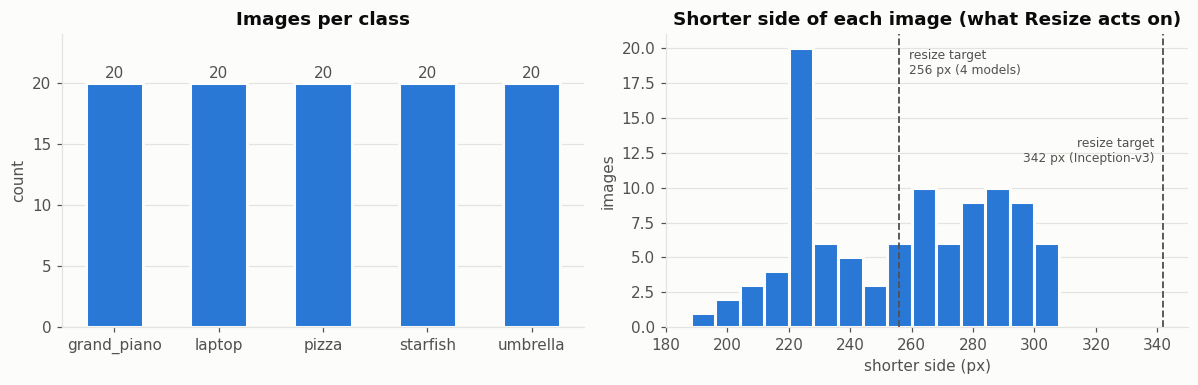

In [4]:
all_sizes = pd.DataFrame(
    [(CLASS_NAMES[int(f.parent.name)], *Image.open(f).size) for f in sorted(DATA_DIR.glob("*/*.jpg"))],
    columns=["class", "width", "height"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
counts = all_sizes["class"].value_counts().reindex(CLASS_NAMES.values())
axes[0].bar(counts.index, counts.values, color="#2a78d6", width=0.55, edgecolor=SURFACE, linewidth=2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.4, str(v), ha="center", color=INK_2)
axes[0].set_title("Images per class"); axes[0].set_ylabel("count"); axes[0].set_ylim(0, 24)
axes[0].grid(axis="x", visible=False)

short_side = all_sizes[["width", "height"]].min(axis=1)
axes[1].hist(short_side, bins=np.arange(180, 310, 8), color="#2a78d6", edgecolor=SURFACE, linewidth=2)
for v, lbl, yfrac, ha, dx in [(256, "resize target\n256 px (4 models)", 0.95, "left", 3),
                              (342, "resize target\n342 px (Inception-v3)", 0.65, "right", -3)]:
    axes[1].axvline(v, color=INK_2, ls="--", lw=1.2)
    axes[1].text(v + dx, axes[1].get_ylim()[1] * yfrac, lbl, color=INK_2, fontsize=8, ha=ha, va="top")
axes[1].set_xlim(180, 350); axes[1].grid(axis="x", visible=False)
axes[1].set_title("Shorter side of each image (what Resize acts on)")
axes[1].set_xlabel("shorter side (px)"); axes[1].set_ylabel("images")
plt.tight_layout(); plt.show()

`transforms.Resize(256)` scales the **shorter side** of an image to 256 px. The histogram shows that our shorter sides range
from about 190 to 300 px, so for the four 224-px models some images are slightly shrunk and some slightly enlarged.
For **Inception-v3 every single image must be enlarged** to 342 px (1.1–1.8×) — interpolation makes the picture bigger
but cannot add real detail.

### 2.5 A look at the curated images

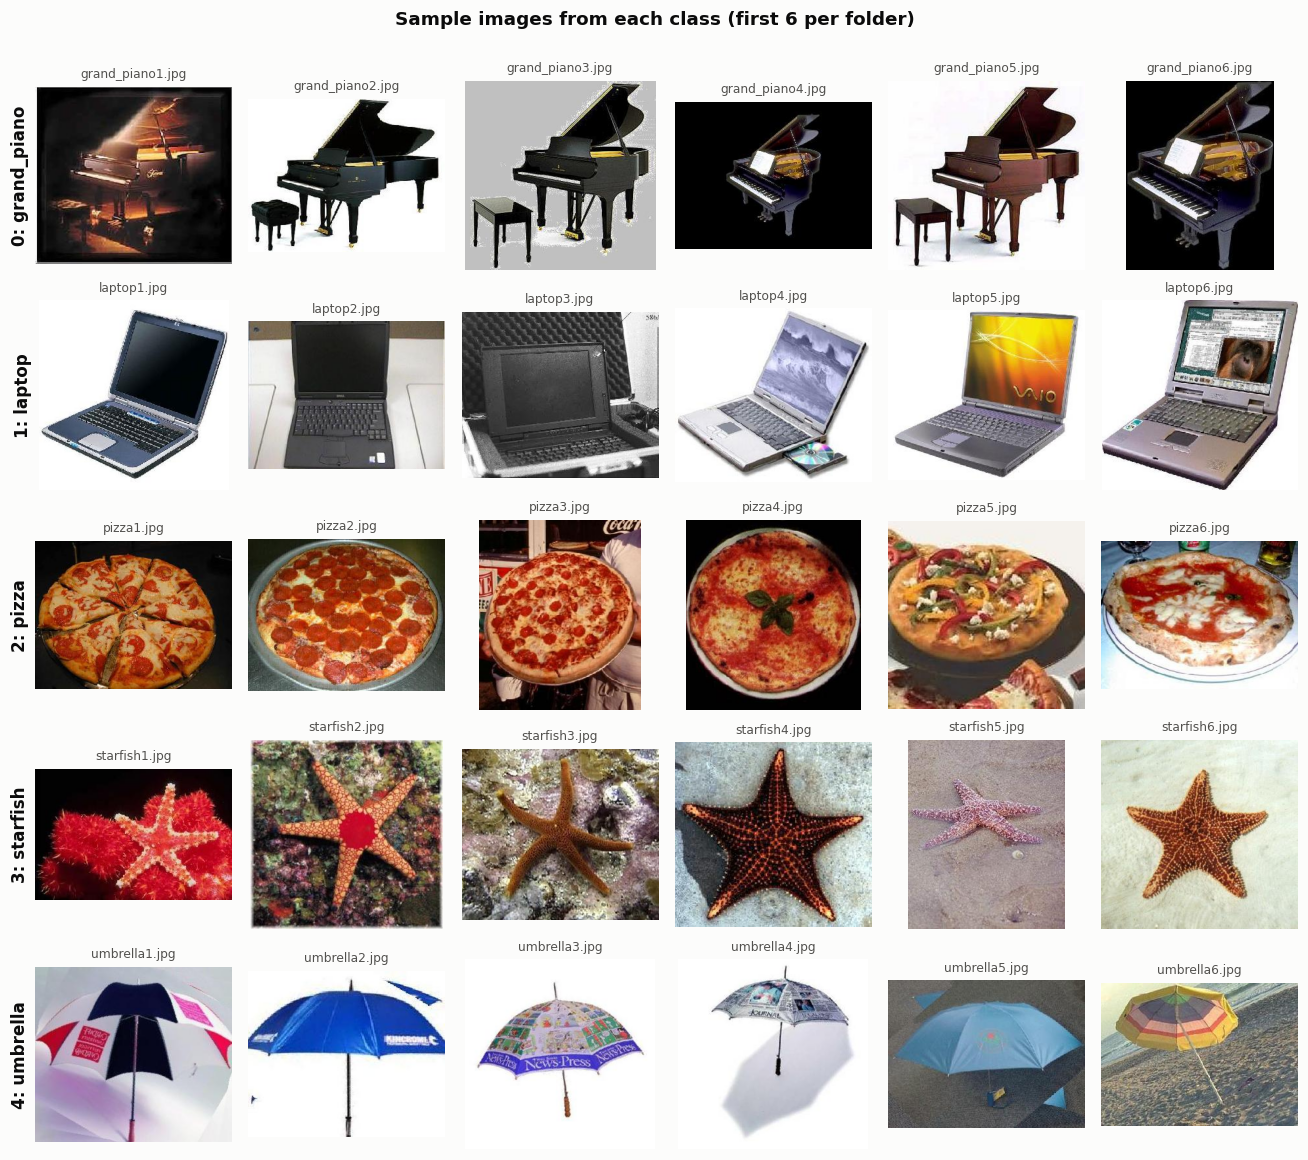

In [5]:
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(12, 10.5))
for c in range(NUM_CLASSES):
    files = sorted((DATA_DIR / str(c)).glob("*.jpg"), key=lambda p: int(re.findall(r"\d+", p.stem)[-1]))
    for j, f in enumerate(files[:6]):
        ax = axes[c, j]
        ax.imshow(Image.open(f).convert("RGB")); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values(): s.set_visible(False)
        ax.set_title(f.name, fontsize=8, color=INK_2, fontweight="normal")
        if j == 0:
            ax.set_ylabel(f"{c}: {CLASS_NAMES[c]}", fontsize=11, color=INK, fontweight="bold")
fig.suptitle("Sample images from each class (first 6 per folder)", fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

## 3. Mapping our labels to ImageNet

A pretrained classifier outputs a vector of **1,000 scores** (logits), one per ImageNet class. Our labels are `0…4`.
We therefore need a translation table from ImageNet indices to our labels.

Why does **laptop map to two ImageNet classes?** ImageNet contains both `laptop` (620) and `notebook` (681,
"notebook computer"). They are practically the same object, and ImageNet's own annotations are known to mix them up.
Punishing a model for answering "notebook" to a laptop photo would measure label noise, not model quality — so both count
as correct. Everything else is a clean 1-to-1 mapping.

Let me verify the indices against the category list that ships with the torchvision weights (so there are no typos):

In [6]:
IMAGENET_CATEGORIES = models.ResNet18_Weights.IMAGENET1K_V1.meta["categories"]   # 1,000 class names

CLASS_TO_IMAGENET = {0: [579], 1: [620, 681], 2: [963], 3: [327], 4: [879]}
IMAGENET_TO_CLASS = {imnet_idx: c for c, idxs in CLASS_TO_IMAGENET.items() for imnet_idx in idxs}
OTHER = NUM_CLASSES            # label 5 = "the model predicted some other ImageNet class"
LABELS_WITH_OTHER = [*CLASS_NAMES.values(), "other"]

pd.DataFrame([{"our label": c, "class": CLASS_NAMES[c],
               "ImageNet index": idx, "ImageNet name": IMAGENET_CATEGORIES[idx]}
              for c, idxs in CLASS_TO_IMAGENET.items() for idx in idxs])

,our label,class,ImageNet index,ImageNet name
0,0,grand_piano,579,grand piano
1,1,laptop,620,laptop
2,1,laptop,681,notebook
3,2,pizza,963,pizza
4,3,starfish,327,starfish
5,4,umbrella,879,umbrella


## 4. Custom PyTorch `Dataset` class

A PyTorch `Dataset` only has to answer two questions:

* `__len__()` → *how many samples are there?*
* `__getitem__(idx)` → *give me sample number `idx`* (image tensor + label)

Design decisions (and the reasoning behind them):

| Decision | Reason |
|---|---|
| Scan folders once in `__init__` and store `(path, label)` pairs | Cheap; images are loaded lazily in `__getitem__`, so memory stays low even for big datasets |
| Label = folder name converted to `int` | Matches the class convention `dataset/0`, `dataset/1`, … |
| **Natural sort** of file names | So `pizza2.jpg` comes before `pizza10.jpg` (plain string sort would not) — gives a stable, human-readable order |
| `.convert("RGB")` on every image | Handles the grayscale image (and any CMYK/RGBA files) → always 3 channels |
| `transform` passed in from outside | Different models need different preprocessing (224 vs 299 px); the same class serves all of them |
| Return `idx` as a third element | Lets us trace every prediction back to its file for error analysis |

In [7]:
def natural_key(path: Path):
    '''Split "pizza10" into ["pizza", 10] so numbers sort numerically.'''
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", path.name)]


class CustomImageDataset(Dataset):
    '''Image-classification dataset stored as  root/<class_id>/<image files>.'''

    IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    def __init__(self, root, transform=None, class_names=None):
        self.root = Path(root)
        self.transform = transform

        # every sub-folder whose name is a number is one class
        class_dirs = sorted((d for d in self.root.iterdir() if d.is_dir() and d.name.isdigit()),
                            key=lambda d: int(d.name))
        if not class_dirs:
            raise FileNotFoundError(f"No numbered class folders found in {self.root}")

        self.samples = []                      # list of (file path, integer label)
        for d in class_dirs:
            for f in sorted(d.iterdir(), key=natural_key):
                if f.suffix.lower() in self.IMG_EXTENSIONS:
                    self.samples.append((f, int(d.name)))

        self.targets = [label for _, label in self.samples]
        self.class_names = class_names or {int(d.name): d.name for d in class_dirs}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")      # guarantees 3 channels
        if self.transform is not None:
            image = self.transform(image)
        return image, label, idx

    def __repr__(self):
        counts = Counter(self.targets)
        per_class = ", ".join(f"{self.class_names[c]}={n}" for c, n in sorted(counts.items()))
        return f"CustomImageDataset(root='{self.root}', n={len(self)}, {per_class})"

**Sanity check** — create the dataset *without* a transform (so we get PIL images back) and inspect a few samples,
including the grayscale one, to confirm the conversion works.

In [8]:
raw_ds = CustomImageDataset(DATA_DIR, transform=None, class_names=CLASS_NAMES)
print(raw_ds)
print("len(raw_ds) =", len(raw_ds))

img, label, idx = raw_ds[0]
print(f"\nSample 0 -> file={raw_ds.samples[0][0]}, label={label} ({CLASS_NAMES[label]}), "
      f"type={type(img).__name__}, size={img.size}, mode={img.mode}")

gray_files = [p for p, _ in raw_ds.samples if Image.open(p).mode != "RGB"]
for p in gray_files:
    i = [s[0] for s in raw_ds.samples].index(p)
    print(f"Originally non-RGB: {p}  ({Image.open(p).mode})  ->  after __getitem__: mode={raw_ds[i][0].mode}")

CustomImageDataset(root='dataset', n=100, grand_piano=20, laptop=20, pizza=20, starfish=20, umbrella=20)
len(raw_ds) = 100

Sample 0 -> file=dataset/0/grand_piano1.jpg, label=0 (grand_piano), type=Image, size=(300, 271), mode=RGB
Originally non-RGB: dataset/1/laptop3.jpg  (L)  ->  after __getitem__: mode=RGB


## 5. Pre-processing: what does each model expect?

A pretrained model only works well if the input looks like what it saw during training. For ImageNet models that means:

1. **Resize** the shorter side (256 px for most models, **342 px for Inception-v3**)
2. **Center-crop** to the training resolution (**224×224**, or **299×299 for Inception-v3**)
3. **Convert to a tensor** with values in [0, 1] and shape `C×H×W`
4. **Normalize** each channel with the ImageNet mean `[0.485, 0.456, 0.406]` and std `[0.229, 0.224, 0.225]`

Instead of hard-coding these numbers, I use `weights.transforms()` — every torchvision weight object carries the exact
preprocessing it was trained with. This avoids a classic bug: feeding Inception-v3 a 224 px image.

In [9]:
MODEL_SPECS = {
    "ResNet-18":    (models.resnet18,     models.ResNet18_Weights.IMAGENET1K_V1),
    "ResNet-50":    (models.resnet50,     models.ResNet50_Weights.IMAGENET1K_V1),
    "DenseNet-121": (models.densenet121,  models.DenseNet121_Weights.IMAGENET1K_V1),
    "MobileNetV2":  (models.mobilenet_v2, models.MobileNet_V2_Weights.IMAGENET1K_V1),
    "Inception-v3": (models.inception_v3, models.Inception_V3_Weights.IMAGENET1K_V1),
}
MODEL_NAMES = list(MODEL_SPECS)
COLOR_OF = dict(zip(MODEL_NAMES, MODEL_COLORS))

for name, (_, weights) in MODEL_SPECS.items():
    t = weights.transforms()
    print(f"{name:<13} resize={t.resize_size}  crop={t.crop_size}  mean={t.mean}  std={t.std}")

ResNet-18     resize=[256]  crop=[224]  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]
ResNet-50     resize=[256]  crop=[224]  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]
DenseNet-121  resize=[256]  crop=[224]  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]
MobileNetV2   resize=[256]  crop=[224]  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]
Inception-v3  resize=[342]  crop=[299]  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


To *see* what the preprocessing does, the next cell pushes one image through both pipelines and undoes the
normalization for display:

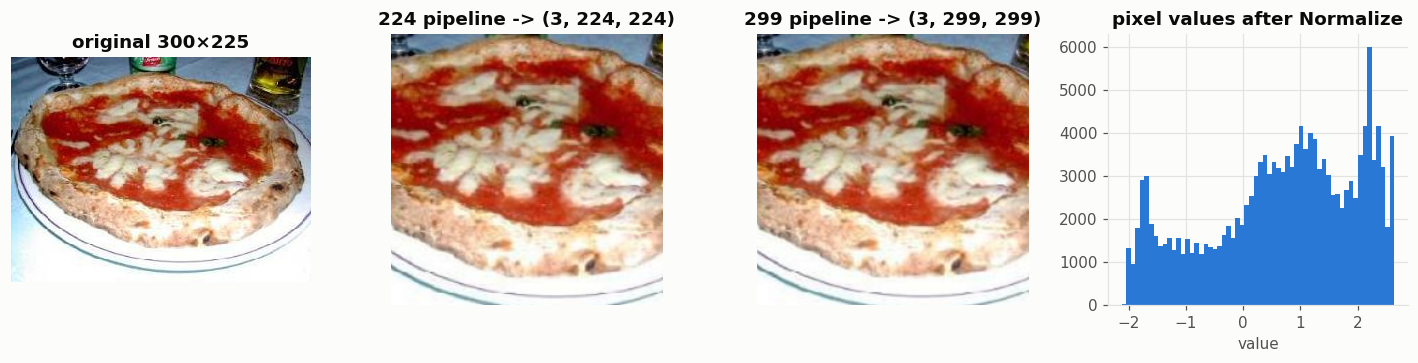

Before Normalize: values in [0, 1].  After: min=-2.12, max=2.64, mean=0.70, std=1.29


In [10]:
def denormalize(t, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    return (t * torch.tensor(std)[:, None, None] + torch.tensor(mean)[:, None, None]).clamp(0, 1)

sample_img, sample_lbl, _ = raw_ds[45]      # a pizza
t224 = MODEL_SPECS["ResNet-50"][1].transforms()
t299 = MODEL_SPECS["Inception-v3"][1].transforms()
x224, x299 = t224(sample_img), t299(sample_img)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
axes[0].imshow(sample_img); axes[0].set_title(f"original {sample_img.size[0]}×{sample_img.size[1]}")
axes[1].imshow(denormalize(x224).permute(1, 2, 0)); axes[1].set_title(f"224 pipeline -> {tuple(x224.shape)}")
axes[2].imshow(denormalize(x299).permute(1, 2, 0)); axes[2].set_title(f"299 pipeline -> {tuple(x299.shape)}")
axes[3].hist(x224.flatten().numpy(), bins=60, color="#2a78d6")
axes[3].set_title("pixel values after Normalize"); axes[3].set_xlabel("value")
for ax in axes[:3]:
    ax.axis("off")
plt.tight_layout(); plt.show()
print(f"Before Normalize: values in [0, 1].  After: min={x224.min():.2f}, max={x224.max():.2f}, "
      f"mean={x224.mean():.2f}, std={x224.std():.2f}")

After `Normalize`, a value of 0 means "an average ImageNet pixel" and ±1 means one ImageNet standard deviation away.
This single pizza photo is brighter/redder than the average ImageNet image, so its mean is above 0 — that is expected;
only the *whole* ImageNet set is centred on zero. The important point is that the network receives numbers on the same
scale it was trained on. Section 10 shows what happens when we skip this step.

## 6. `DataLoader`s for evaluation

The `DataLoader` wraps the `Dataset` and serves it in batches. Settings chosen for *evaluation*:

| Argument | Value | Why |
|---|---|---|
| `batch_size` | 16 | Small dataset; 16 fits comfortably in CPU/GPU memory and gives 7 batches |
| `shuffle` | `False` | Order does not matter for evaluation, and a fixed order makes results reproducible and easy to trace |
| `drop_last` | `False` (default) | We must evaluate **every** image, including the last incomplete batch of 4 |
| `num_workers` | 0 | 100 small JPEGs load instantly; extra worker processes would only add start-up overhead (and cause issues on Windows notebooks) |
| `pin_memory` | only on GPU | Speeds up host→GPU copies |

Because the two input resolutions differ, each model gets **its own loader built from its own transform**, all reading
the same files.

In [11]:
BATCH_SIZE = 16

def make_loader(transform, batch_size=BATCH_SIZE):
    ds = CustomImageDataset(DATA_DIR, transform=transform, class_names=CLASS_NAMES)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0,
                      pin_memory=(DEVICE.type == "cuda"))

loaders = {name: make_loader(weights.transforms()) for name, (_, weights) in MODEL_SPECS.items()}

for name, loader in loaders.items():
    images, labels, idxs = next(iter(loader))
    print(f"{name:<13} batches={len(loader)}  first batch: images{tuple(images.shape)}  "
          f"labels{tuple(labels.shape)}  labels[:6]={labels[:6].tolist()}")

ResNet-18     batches=7  first batch: images(16, 3, 224, 224)  labels(16,)  labels[:6]=[0, 0, 0, 0, 0, 0]
ResNet-50     batches=7  first batch: images(16, 3, 224, 224)  labels(16,)  labels[:6]=[0, 0, 0, 0, 0, 0]
DenseNet-121  batches=7  first batch: images(16, 3, 224, 224)  labels(16,)  labels[:6]=[0, 0, 0, 0, 0, 0]
MobileNetV2   batches=7  first batch: images(16, 3, 224, 224)  labels(16,)  labels[:6]=[0, 0, 0, 0, 0, 0]


Inception-v3  batches=7  first batch: images(16, 3, 299, 299)  labels(16,)  labels[:6]=[0, 0, 0, 0, 0, 0]


The shapes confirm the pipeline: `[batch, channels, height, width]` = `[16, 3, 224, 224]` for four models and
`[16, 3, 299, 299]` for Inception-v3, 7 batches each (6×16 + 4 = 100 images).

## 7. The five pretrained models

I chose the five models to cover **different design ideas**, not just different sizes of the same network:

| Model | Year | Key idea | Why it is in the comparison |
|---|---|---|---|
| **ResNet-18** | 2015 | Residual (skip) connections let gradients flow through deep nets | Small, classic baseline |
| **ResNet-50** | 2015 | Same idea, deeper, with 1×1 "bottleneck" blocks | Shows the effect of depth within the same family |
| **DenseNet-121** | 2017 | Every layer receives the feature maps of *all* previous layers (feature reuse) | Different connectivity pattern, very parameter-efficient |
| **MobileNetV2** | 2018 | Depthwise-separable convs + inverted residuals, built for phones | The "lightweight / edge device" option |
| **Inception-v3** | 2015 | Parallel convolution branches of different sizes (multi-scale), factorised convolutions | Different input requirement (299 px) |

All five use `IMAGENET1K_V1` weights (the original torchvision checkpoints). The table below reads the size, compute cost
and official ImageNet accuracy straight from the weight metadata:

In [12]:
info_rows = []
for name, (_, w) in MODEL_SPECS.items():
    m = w.meta
    info_rows.append({
        "model": name,
        "params (M)": m["num_params"] / 1e6,
        "GFLOPs": m["_ops"],
        "input": f'{w.transforms().crop_size[0]}×{w.transforms().crop_size[0]}',
        "file size (MB)": m["_file_size"],
        "ImageNet top-1 (%)": m["_metrics"]["ImageNet-1K"]["acc@1"],
        "ImageNet top-5 (%)": m["_metrics"]["ImageNet-1K"]["acc@5"],
    })
model_info = pd.DataFrame(info_rows).set_index("model")
model_info

,params (M),GFLOPs,input,file size (MB),ImageNet top-1 (%),ImageNet top-5 (%)
model,,,,,,
ResNet-18,11.690,1.814,224×224,44.661,69.758,89.078
ResNet-50,25.557,4.089,224×224,97.781,76.130,92.862
DenseNet-121,7.979,2.834,224×224,30.845,74.434,91.972
MobileNetV2,3.505,0.301,224×224,13.555,71.878,90.286
Inception-v3,27.161,5.713,299×299,103.903,77.294,93.450


**What to expect (hypothesis before running anything):** on ImageNet, ResNet-50 ≈ Inception-v3 > DenseNet-121 >
MobileNetV2 > ResNet-18. If our dataset behaves like ImageNet, the ranking should be similar — but with only 100 images
and a different photo source (Caltech-101 is older, lower resolution, many studio/product shots), the ranking may shift.

## 8. Inference and evaluation

### 8.1 Running the models

For each model: load weights → switch to **`model.eval()`** → loop over the loader inside **`torch.inference_mode()`**.

* `eval()` matters: it makes **BatchNorm** use its stored running statistics (instead of statistics of our tiny batch) and
  turns **Dropout** off. For Inception-v3 it also disables the auxiliary classifier output. Forgetting it gives noticeably
  worse and non-deterministic results.
* `inference_mode()` disables gradient tracking → less memory, faster.
* I keep the **raw 1,000 logits** for every image, so that all metrics (top-1, top-5, the two protocols below) can be
  computed afterwards without re-running the models.
* Timing: one warm-up batch is run first (the first call is always slower due to memory allocation), then the average
  time per image is measured. Absolute times depend on the hardware, so only the *relative* speeds are meaningful.

In [13]:
@torch.inference_mode()
def run_inference(model, loader, device=DEVICE):
    model.eval().to(device)
    warm = next(iter(loader))[0].to(device)
    model(warm)                                             # warm-up pass (not timed)

    logits_all, labels_all, idx_all, elapsed = [], [], [], 0.0
    for images, labels, idxs in loader:
        images = images.to(device)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        logits = model(images)
        if device.type == "cuda": torch.cuda.synchronize()
        elapsed += time.perf_counter() - t0
        logits_all.append(logits.float().cpu()); labels_all.append(labels); idx_all.append(idxs)

    n = len(loader.dataset)
    return {"logits": torch.cat(logits_all), "labels": torch.cat(labels_all).numpy(),
            "idx": torch.cat(idx_all).numpy(), "ms_per_img": 1000 * elapsed / n}


raw_results = {}
for name, (builder, weights) in MODEL_SPECS.items():
    model = builder(weights=weights)
    raw_results[name] = run_inference(model, loaders[name])
    print(f"{name:<13} done  | logits {tuple(raw_results[name]['logits'].shape)} "
          f"| {raw_results[name]['ms_per_img']:.1f} ms/image")
    del model

ResNet-18     done  | logits (100, 1000) | 24.4 ms/image


ResNet-50     done  | logits (100, 1000) | 72.6 ms/image


DenseNet-121  done  | logits (100, 1000) | 59.0 ms/image


MobileNetV2   done  | logits (100, 1000) | 18.0 ms/image


Inception-v3  done  | logits (100, 1000) | 114.2 ms/image


### 8.2 From 1,000 ImageNet scores to our 5 labels — two evaluation protocols

There are two sensible ways to turn the 1,000-way output into a prediction for our dataset, and they answer different questions:

**Protocol A — Open-set (strict, 1,000-way).** Take the model's top-1 ImageNet class. If it maps to one of our classes,
that is the prediction; otherwise the prediction is **"other"** (e.g. the model said *upright piano* or *parachute*).
→ *"Does the model recognise the object, out of all 1,000 things it knows?"* This is the **main protocol** of this lab
because it is the honest, real-world use of an off-the-shelf model.

**Protocol B — Closed-set (restricted to our 5 classes).** Convert logits to probabilities with softmax, add up the
probability of the ImageNet classes belonging to each of our classes (laptop = P(laptop) + P(notebook)), and pick
the largest of the 5. → *"If we tell the model the answer is one of these five, does it pick the right one?"*
This is how you would deploy the model on a known set of categories without retraining.

We also report **top-5 accuracy** (open-set: correct if any of the top-5 ImageNet guesses maps to the true class) and
**Mean P(true)** — the average softmax probability the model assigns to the correct class. Accuracy only checks whether the
right answer *won*; Mean P(true) also tells us *how confidently* it won, which separates models even when their accuracies tie.

**How the metrics treat "other":** precision, recall and F1 are computed for our 5 real classes and **macro-averaged**
(simple mean over classes — appropriate because the classes are balanced and equally important). An "other" prediction
counts as a **miss** (lowers recall of the true class) but does not count against any class's precision, since the
model did not wrongly claim another of our classes.

In [14]:
def open_set_predictions(logits):
    top1 = logits.argmax(dim=1).numpy()
    mapped = np.array([IMAGENET_TO_CLASS.get(int(i), OTHER) for i in top1])
    return mapped, top1

def closed_set_predictions(logits):
    probs = logits.softmax(dim=1)
    class_scores = torch.stack([probs[:, CLASS_TO_IMAGENET[c]].sum(dim=1) for c in range(NUM_CLASSES)], dim=1)
    return class_scores.argmax(dim=1).numpy()

def topk_accuracy(logits, labels, k=5):
    topk = logits.topk(k, dim=1).indices.numpy()
    return np.mean([any(IMAGENET_TO_CLASS.get(int(i)) == y for i in row) for row, y in zip(topk, labels)])

def bootstrap_ci(correct, n_boot=2000, alpha=0.05, seed=SEED):
    '''95% confidence interval of accuracy by resampling the 100 images with replacement.'''
    rng = np.random.default_rng(seed)
    boots = rng.choice(correct, size=(n_boot, len(correct)), replace=True).mean(axis=1)
    return np.quantile(boots, [alpha / 2, 1 - alpha / 2])

def mean_true_prob(logits, labels):
    '''Average softmax probability (over all 1,000 classes) that the model puts on the correct class.'''
    probs = logits.softmax(dim=1)
    return float(np.mean([probs[i, CLASS_TO_IMAGENET[y]].sum().item() for i, y in enumerate(labels)]))

def macro_prf(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                                                 average="macro", zero_division=0)
    return p, r, f


preds, rows = {}, []
for name, res in raw_results.items():
    y = res["labels"]
    y_open, top1_imagenet = open_set_predictions(res["logits"])
    y_closed = closed_set_predictions(res["logits"])
    preds[name] = {"open": y_open, "closed": y_closed, "top1_imagenet": top1_imagenet}

    p_o, r_o, f_o = macro_prf(y, y_open)
    p_c, r_c, f_c = macro_prf(y, y_closed)
    lo, hi = bootstrap_ci((y_open == y).astype(float))
    rows.append({
        "model": name,
        "Accuracy": accuracy_score(y, y_open), "95% CI": f"{lo:.2f}–{hi:.2f}",
        "Precision": p_o, "Recall": r_o, "F1": f_o,
        "Top-5 Acc": topk_accuracy(res["logits"], y),
        "Mean P(true)": mean_true_prob(res["logits"], y),
        "'other' preds": int((y_open == OTHER).sum()),
        "Closed Acc": accuracy_score(y, y_closed), "Closed F1": f_c,
        "params (M)": model_info.loc[name, "params (M)"], "GFLOPs": model_info.loc[name, "GFLOPs"],
        "ms/img": res["ms_per_img"],
        "ImageNet top-1 (%)": model_info.loc[name, "ImageNet top-1 (%)"],
    })

results = pd.DataFrame(rows).set_index("model")
results.round(3)

,Accuracy,95% CI,Precision,Recall,F1,Top-5 Acc,Mean P(true),'other' preds,Closed Acc,Closed F1,params (M),GFLOPs,ms/img,ImageNet top-1 (%)
model,,,,,,,,,,,,,,
ResNet-18,0.79,0.70–0.87,1.0,0.79,0.871,0.96,0.724,21,1.0,1.0,11.690,1.814,24.351,69.758
ResNet-50,0.85,0.77–0.91,1.0,0.85,0.915,0.99,0.777,15,1.0,1.0,25.557,4.089,72.551,76.130
DenseNet-121,0.88,0.81–0.94,1.0,0.88,0.932,0.99,0.749,12,1.0,1.0,7.979,2.834,59.043,74.434
MobileNetV2,0.79,0.70–0.87,1.0,0.79,0.879,0.97,0.724,21,1.0,1.0,3.505,0.301,17.966,71.878
Inception-v3,0.91,0.85–0.96,1.0,0.91,0.951,1.00,0.746,9,1.0,1.0,27.161,5.713,114.201,77.294


## 9. Model comparison

### 9.1 Summary table

Best value in each metric column is highlighted (for `ms/img`, `params` and `GFLOPs` lower is better).

In [15]:
higher_better = ["Accuracy", "Precision", "Recall", "F1", "Top-5 Acc", "Mean P(true)", "Closed Acc", "Closed F1"]
lower_better = ["'other' preds", "params (M)", "GFLOPs", "ms/img"]
fmt = {c: "{:.3f}" for c in higher_better} | {"params (M)": "{:.1f}", "GFLOPs": "{:.2f}",
                                              "ms/img": "{:.1f}", "ImageNet top-1 (%)": "{:.2f}"}
(results.sort_values("F1", ascending=False)
        .style.format(fmt)
        .highlight_max(subset=higher_better, props="background-color:#cde2fb; font-weight:bold")
        .highlight_min(subset=lower_better, props="background-color:#cde2fb; font-weight:bold"))

,Accuracy,95% CI,Precision,Recall,F1,Top-5 Acc,Mean P(true),'other' preds,Closed Acc,Closed F1,params (M),GFLOPs,ms/img,ImageNet top-1 (%)
model,,,,,,,,,,,,,,
Inception-v3,0.910,0.85–0.96,1.000,0.910,0.951,1.000,0.746,9,1.000,1.000,27.2,5.71,114.2,77.29
DenseNet-121,0.880,0.81–0.94,1.000,0.880,0.932,0.990,0.749,12,1.000,1.000,8.0,2.83,59.0,74.43
ResNet-50,0.850,0.77–0.91,1.000,0.850,0.915,0.990,0.777,15,1.000,1.000,25.6,4.09,72.6,76.13
MobileNetV2,0.790,0.70–0.87,1.000,0.790,0.879,0.970,0.724,21,1.000,1.000,3.5,0.30,18.0,71.88
ResNet-18,0.790,0.70–0.87,1.000,0.790,0.871,0.960,0.724,21,1.000,1.000,11.7,1.81,24.4,69.76


### 9.2 Metric comparison (open-set protocol)

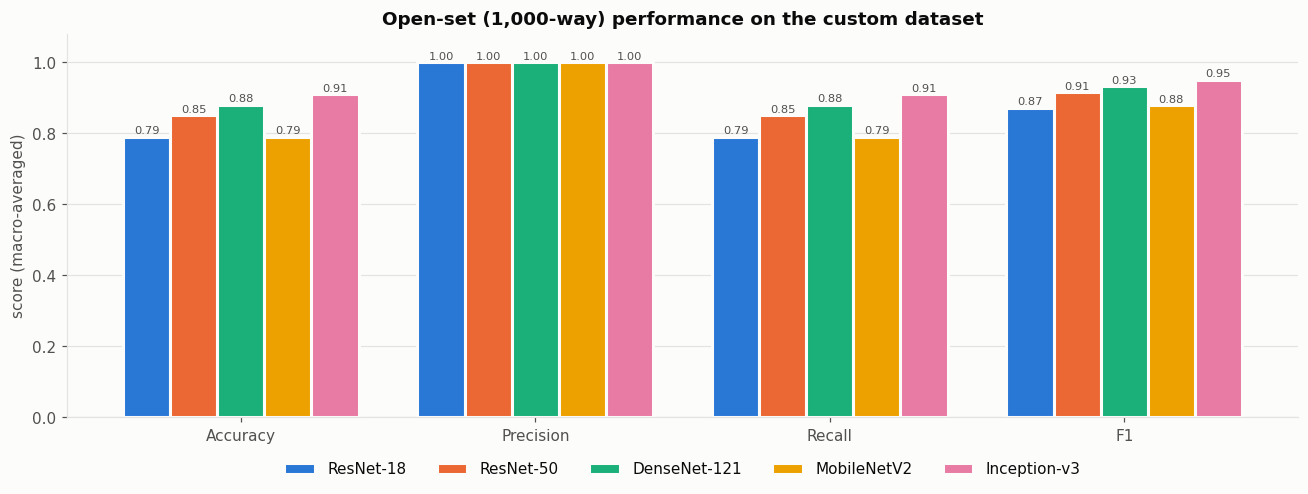

In [16]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics)); w = 0.16
fig, ax = plt.subplots(figsize=(12, 4.6))
for i, name in enumerate(MODEL_NAMES):
    vals = results.loc[name, metrics].values
    bars = ax.bar(x + (i - 2) * w, vals, w, label=name, color=COLOR_OF[name], edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.2f}", ha="center", fontsize=7.5, color=INK_2)
ax.set_xticks(x, metrics); ax.set_ylim(0, 1.08); ax.set_ylabel("score (macro-averaged)")
ax.set_title("Open-set (1,000-way) performance on the custom dataset")
ax.grid(axis="x", visible=False)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(); plt.show()

> **Observation.** Accuracy, recall and F1 rank the models the same way: **Inception-v3 (0.91) > DenseNet-121 (0.88) > ResNet-50 (0.85) > ResNet-18 ≈ MobileNetV2 (0.79)**.
> **Precision is 1.00 for every model.** That is not a bug: across all 500 predictions no model ever confused one of *our* classes with *another of our classes* (e.g. never called a pizza an umbrella). Every error was an "other" prediction, which lowers recall but not precision. So on this dataset precision is uninformative, and **recall (= accuracy, because the classes are balanced) carries all the differences**. F1, being the harmonic mean of the two, simply follows recall.

### 9.3 How much does restricting the label space help? (open-set vs closed-set)

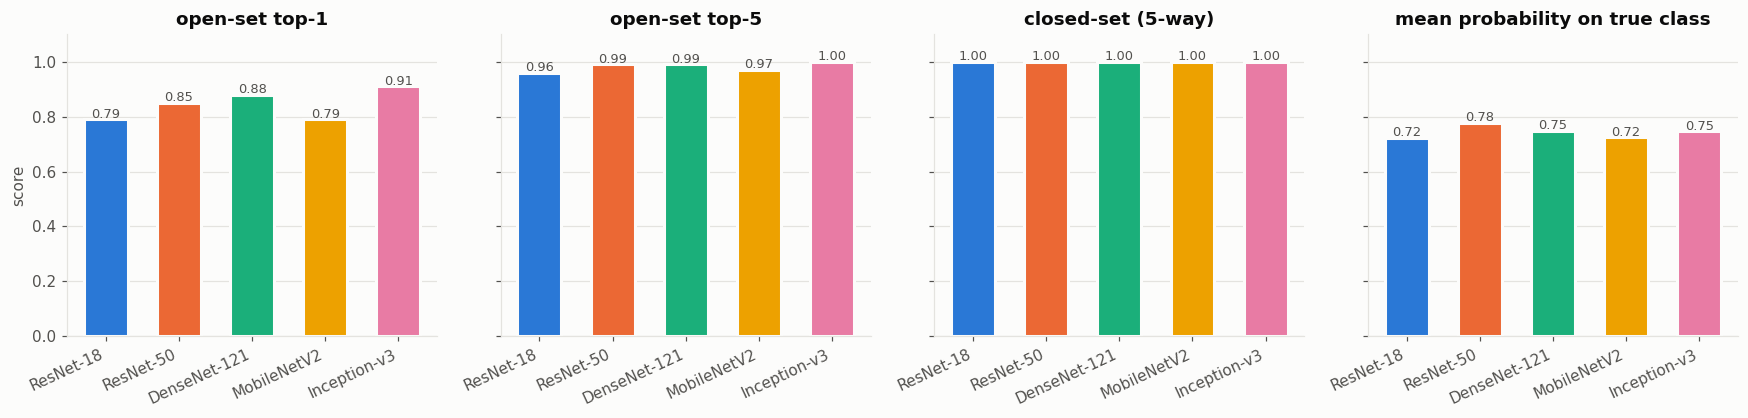

In [17]:
cmp_cols = [("Accuracy", "open-set top-1"), ("Top-5 Acc", "open-set top-5"),
            ("Closed Acc", "closed-set (5-way)"), ("Mean P(true)", "mean probability on true class")]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.9), sharey=True)
for ax, (col, title) in zip(axes, cmp_cols):
    vals = results.loc[MODEL_NAMES, col].values
    bars = ax.bar(range(5), vals, color=MODEL_COLORS, width=0.6, edgecolor=SURFACE, linewidth=2)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.2f}", ha="center", fontsize=8.5, color=INK_2)
    ax.set_xticks(range(5), MODEL_NAMES, rotation=25, ha="right"); ax.set_title(title)
    ax.set_ylim(0, 1.1); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("score")
plt.tight_layout(); plt.show()

> **Observation.** The picture changes completely with the protocol:
> * **Top-5 accuracy is 0.96–1.00** — even when a model's first guess is wrong, the correct class is almost always among its next four guesses.
> * **Closed-set accuracy is 100% for all five models.** Once the model only has to choose between our five classes, the task is trivially easy — the classes are visually very different from each other.
>
> So the models *do* know what the objects are; the errors come from competition with **neighbouring ImageNet classes** (Section 9.6), not from failing to see the object.
> The **mean probability on the true class** adds a twist: **ResNet-50 is the most confident (0.78)**, while Inception-v3 — the most *accurate* — is only 0.75. Inception-v3 was trained with **label smoothing**, a regulariser that deliberately stops the network from putting ~100% on one class, so its correct answers win by smaller margins. Accuracy and confidence are different things.

### 9.4 Confusion matrices

Rows = true class, columns = predicted class (open-set). The extra **"other"** column collects predictions that fell outside
our five classes — this is where almost all errors go.

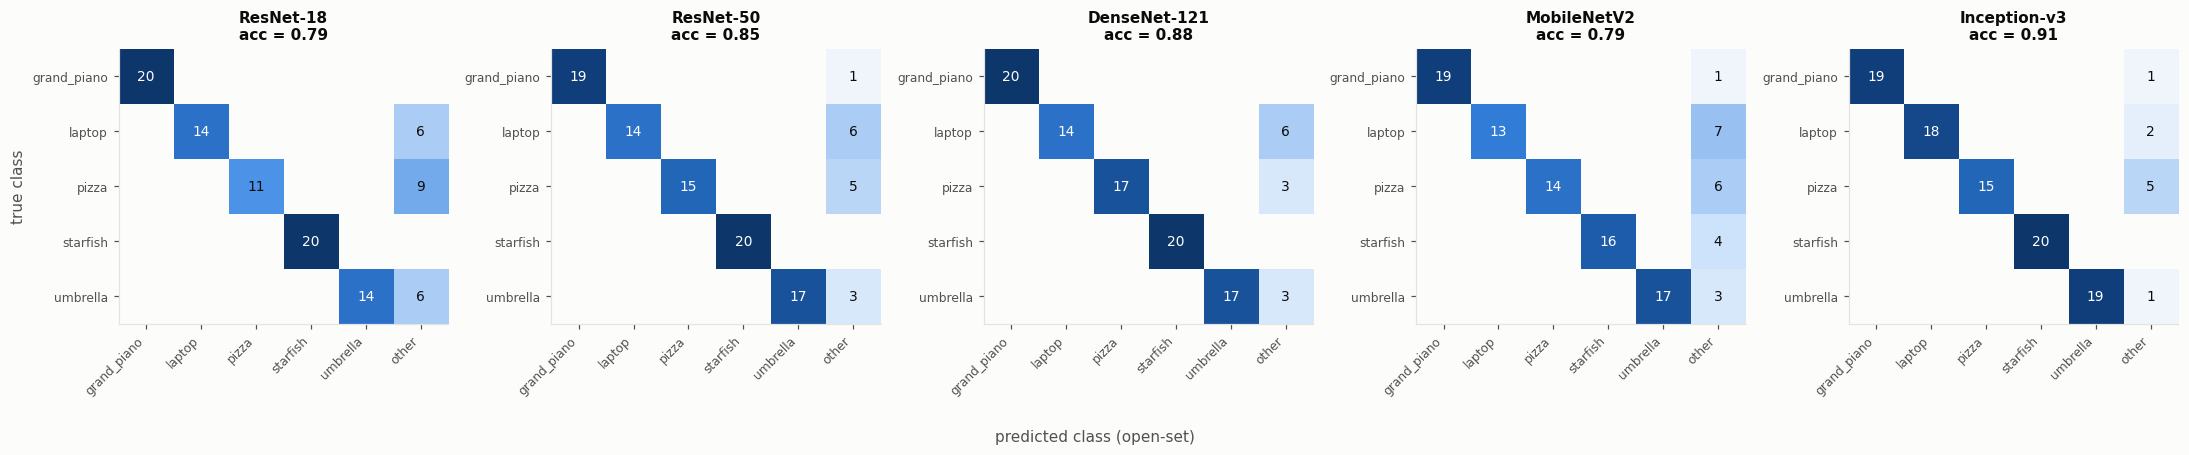

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.4))
for ax, name in zip(axes, MODEL_NAMES):
    cm = confusion_matrix(raw_results[name]["labels"], preds[name]["open"], labels=list(range(NUM_CLASSES + 1)))
    cm = cm[:NUM_CLASSES]                                   # no true 'other' row
    ax.imshow(cm, cmap=SEQ_BLUE, vmin=0, vmax=20)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                        color="white" if cm[i, j] > 12 else INK)
    ax.set_xticks(range(NUM_CLASSES + 1), LABELS_WITH_OTHER, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES.values(), fontsize=8)
    ax.set_title(f"{name}\nacc = {results.loc[name, 'Accuracy']:.2f}", fontsize=10)
    ax.grid(False)
axes[0].set_ylabel("true class")
fig.supxlabel("predicted class (open-set)", color=INK_2, fontsize=10)
plt.tight_layout(); plt.show()

> **Observation.** All confusion matrices are *diagonal + one "other" column*: there is no off-diagonal confusion between our classes at all. **Starfish and grand piano are the easy classes** (≈20/20 for almost every model — both have a very distinctive silhouette). **Laptop and pizza are the hard classes** — ResNet-18 recognised only 11/20 pizzas and most models only 13–14/20 laptops. Inception-v3 is the only model that fixes most laptop errors (18/20). MobileNetV2 is the only model that loses starfish (4 misses).

### 9.5 Per-class F1 score

Which classes are easy for every model, and which separate the good models from the weaker ones?

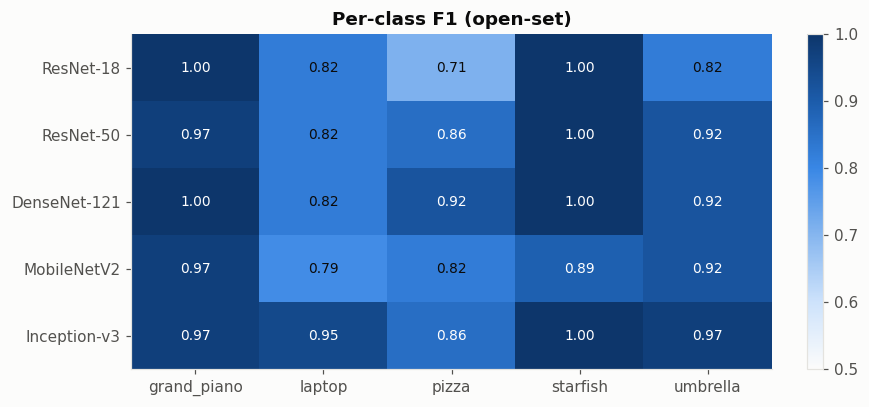

,grand_piano,laptop,pizza,starfish,umbrella
ResNet-18,1.000,0.824,0.710,1.000,0.824
ResNet-50,0.974,0.824,0.857,1.000,0.919
DenseNet-121,1.000,0.824,0.919,1.000,0.919
MobileNetV2,0.974,0.788,0.824,0.889,0.919
Inception-v3,0.974,0.947,0.857,1.000,0.974


In [19]:
per_class_f1 = pd.DataFrame({
    name: precision_recall_fscore_support(raw_results[name]["labels"], preds[name]["open"],
                                          labels=list(range(NUM_CLASSES)), zero_division=0)[2]
    for name in MODEL_NAMES}, index=list(CLASS_NAMES.values())).T

fig, ax = plt.subplots(figsize=(8, 3.8))
im = ax.imshow(per_class_f1.values, cmap=SEQ_BLUE, vmin=0.5, vmax=1.0, aspect="auto")
for i in range(per_class_f1.shape[0]):
    for j in range(per_class_f1.shape[1]):
        v = per_class_f1.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.85 else INK)
ax.set_xticks(range(NUM_CLASSES), per_class_f1.columns); ax.set_yticks(range(5), per_class_f1.index)
ax.set_title("Per-class F1 (open-set)"); ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()
per_class_f1.round(3)

> **Observation.** The heatmap shows *where* the stronger models earn their advantage: almost every model is near-perfect on grand piano and starfish (MobileNetV2's 0.89 on starfish is the exception), so the ranking is decided on **pizza, laptop and umbrella**. The biggest single gap is pizza: ResNet-18 scores F1 0.71, DenseNet-121 0.92. Inception-v3's lead comes mainly from **laptop (0.95 vs 0.79–0.82 for the others)**.

### 9.6 What did the models answer when they were wrong?

Looking at the actual ImageNet label behind each "other" prediction tells us whether a mistake is *silly*
(unrelated object) or *reasonable* (a neighbouring ImageNet class).

In [20]:
wrong_rows = []
for name in MODEL_NAMES:
    y = raw_results[name]["labels"]
    for i in np.where(preds[name]["open"] != y)[0]:
        wrong_rows.append({"model": name, "true class": CLASS_NAMES[y[i]],
                           "predicted ImageNet class": IMAGENET_CATEGORIES[preds[name]["top1_imagenet"][i]]})
wrong = pd.DataFrame(wrong_rows)

summary = (wrong.groupby(["true class", "predicted ImageNet class"])
                .agg(times=("model", "size"), models=("model", lambda s: ", ".join(sorted(set(s)))))
                .sort_values("times", ascending=False))
print(f"Total wrong predictions over all 5 models: {len(wrong)} (out of {5 * len(raw_ds)})")
summary.head(15)

Total wrong predictions over all 5 models: 78 (out of 500)


times  \
true class predicted ImageNet class          
laptop     hand-held computer            9   
pizza      trifle                        8   
           potpie                        7   
laptop     space bar                     6   
umbrella   parachute                     4   
laptop     desktop computer              3   
pizza      meat loaf                     3   
umbrella   mountain tent                 2   
           patio                         2   
           yurt                          2   
           flagpole                      2   
pizza      bakery                        2   
laptop     stove                         2   
umbrella   table lamp                    2   
laptop     photocopier                   2   

                                                                                models  
true class predicted ImageNet class                                                     
laptop     hand-held computer          DenseNet-121, MobileNetV2, ResNet-18, ResNet-50  
pizza      trifle                      Inception-v3, MobileNetV2, ResNet-18, ResNet-50  
           potpie                    DenseNet-121, Inception-v3, MobileNetV2, ResNe...  
laptop     space bar                 DenseNet-121, Inception-v3, MobileNetV2, ResNe...  
umbrella   parachute                                Inception-v3, ResNet-18, ResNet-50  
laptop     desktop computer                    DenseNet-121, Inception-v3, MobileNetV2  
pizza      meat loaf                              Inception-v3, MobileNetV2, ResNet-18  
umbrella   mountain tent                                                     ResNet-18  
           patio                                               DenseNet-121, ResNet-50  
           yurt                                                 MobileNetV2, ResNet-18  
           flagpole                                            DenseNet-121, ResNet-18  
pizza      bakery                                               MobileNetV2, ResNet-18  
laptop     stove                                                MobileNetV2, ResNet-18  
umbrella   table lamp                                        DenseNet-121, MobileNetV2  
laptop     photocopier                                                    DenseNet-121

> **Observation.** Most mistakes are *semantically reasonable* rather than random:
> * **laptop → hand-held computer, space bar, desktop computer, photocopier** — neighbouring "office electronics" classes in ImageNet. "Space bar" is interesting: a close-up keyboard dominates many of these photos. Caltech-101's laptops are also bulky 1990s–early-2000s models, which look different from the laptops in ImageNet.
> * **pizza → trifle, potpie, meat loaf, bakery** — other round, baked, red-and-yellow foods. ImageNet has several dishes that share pizza's colour and texture.
> * **umbrella → parachute, patio, yurt, mountain tent, flagpole** — our patio/beach umbrellas are dome-shaped canopies on a pole, outdoors, which is exactly what parachutes, tents and yurts look like. ImageNet's `umbrella` class is mostly hand-held rain umbrellas.
>
> These errors show that ImageNet's **fine-grained label space** (1,000 classes, many near-synonyms) is the real difficulty, not the images themselves.

### 9.7 The hardest images

For every image, count how many of the five models got it right. Images that fool most models usually reveal a property
of the *data* (ambiguous content, unusual viewpoint), not of one model.

Number of images by how many models classified them correctly:
5    61
4    19
3     9
2     5
1     4
0     2


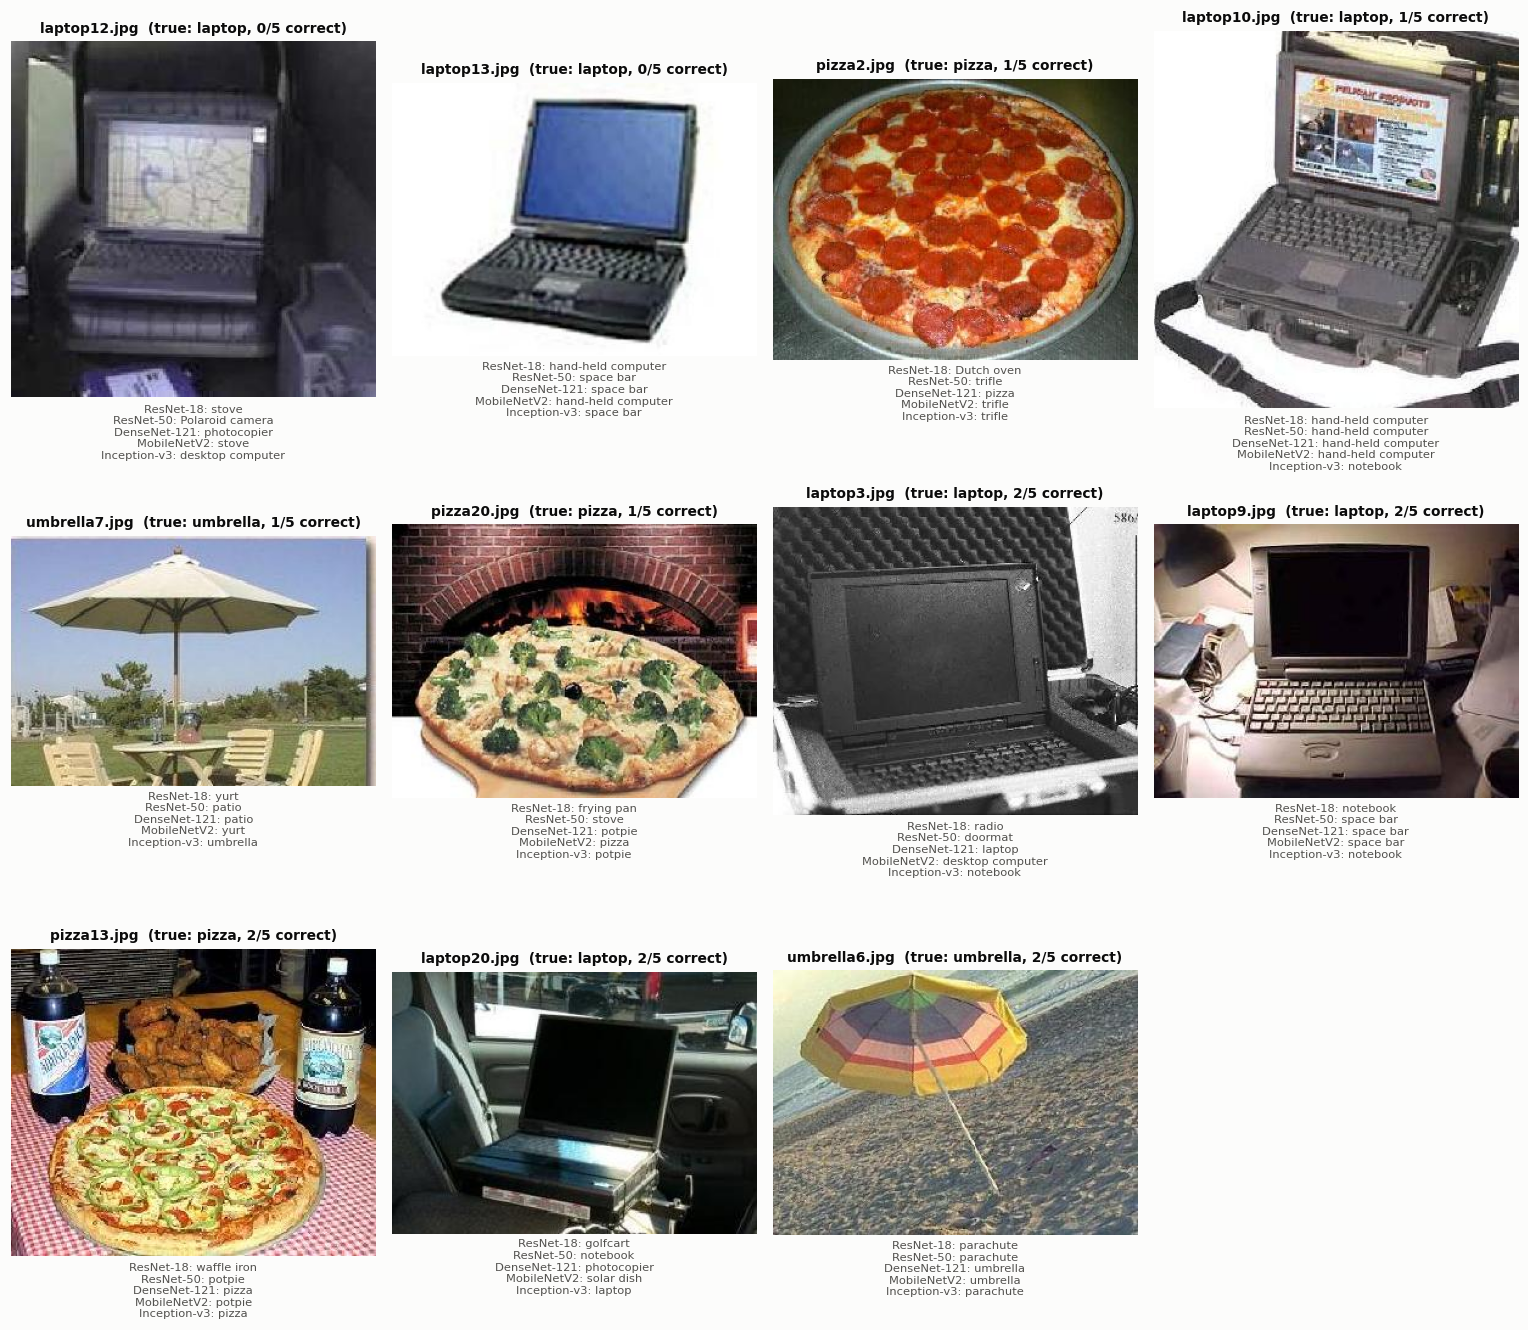

In [21]:
correct_matrix = pd.DataFrame(
    {name: (preds[name]["open"] == raw_results[name]["labels"]).astype(int) for name in MODEL_NAMES},
    index=[raw_ds.samples[i][0].name for i in raw_results[MODEL_NAMES[0]]["idx"]])
n_correct = correct_matrix.sum(axis=1)
print("Number of images by how many models classified them correctly:")
print(n_correct.value_counts().sort_index(ascending=False).rename("images").to_string())

hard = n_correct[n_correct <= 2].sort_values().index.tolist()[:12]
ncols = 4; nrows = int(np.ceil(len(hard) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.1 * nrows))
axes = np.atleast_1d(axes).ravel()
name_to_idx = {raw_ds.samples[i][0].name: i for i in range(len(raw_ds))}
for ax, fname in zip(axes, hard):
    i = name_to_idx[fname]
    img, y, _ = raw_ds[i]
    ax.imshow(img); ax.axis("off")
    guesses = "\n".join(f"{m}: {IMAGENET_CATEGORIES[preds[m]['top1_imagenet'][i]][:22]}" for m in MODEL_NAMES)
    ax.set_title(f"{fname}  (true: {CLASS_NAMES[y]}, {n_correct[fname]}/5 correct)", fontsize=9)
    ax.text(0.5, -0.02, guesses, transform=ax.transAxes, ha="center", va="top", fontsize=7.5, color=INK_2)
for ax in axes[len(hard):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

> **Observation.** 61 of 100 images were classified correctly by all five models, and only **2 images fooled every model** (`laptop12.jpg` — a dark, low-contrast photo with the laptop in a cluttered setting; `laptop13.jpg` — an old, thick 1990s laptop whose keyboard dominates the frame → *space bar* / *hand-held computer*). The hard images share visible causes: **clutter and small object size** (pizza13 on a table with bottles and chicken), **scene context** (pizza20 in front of a brick oven → *stove*, *potpie*), and **patio/beach umbrellas** that look like parachutes or yurts. These are properties of the data, which is why several models fail on the same image.

### 9.8 Accuracy vs. model cost

Bigger is not automatically better. Here each model is placed by its cost (parameters, compute, measured speed)
against its F1 score. Each chart has a single axis scale; the three costs are shown as three separate panels.

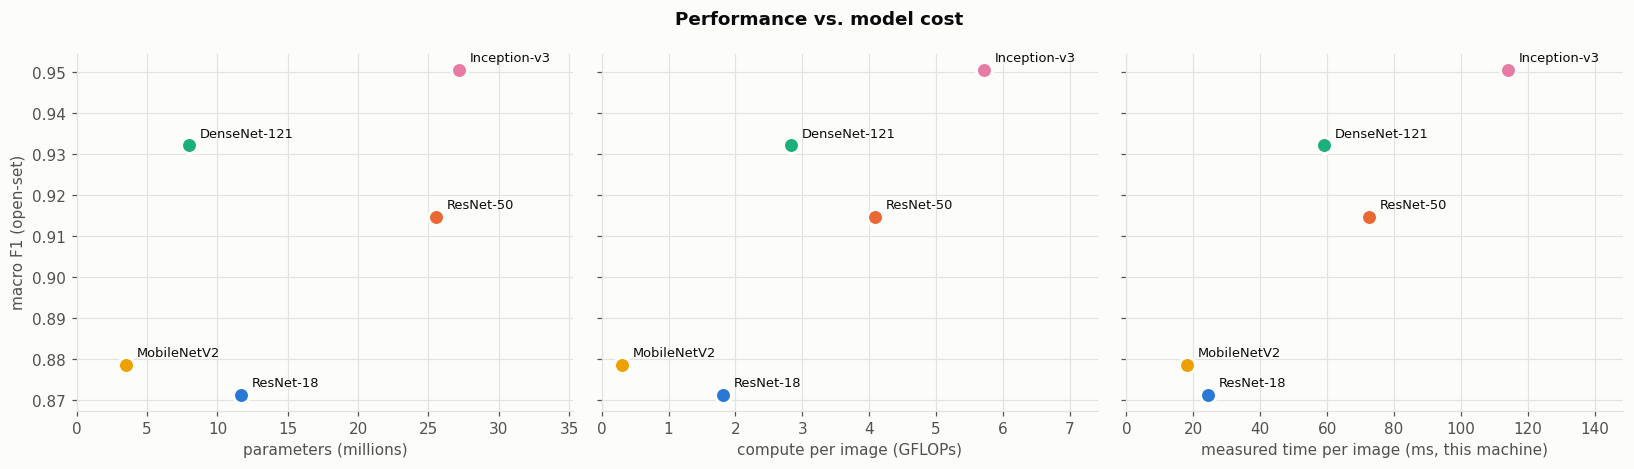

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, (col, xlabel) in zip(axes, [("params (M)", "parameters (millions)"),
                                     ("GFLOPs", "compute per image (GFLOPs)"),
                                     ("ms/img", "measured time per image (ms, this machine)")]):
    for name in MODEL_NAMES:
        xv, yv = results.loc[name, col], results.loc[name, "F1"]
        ax.scatter(xv, yv, s=110, color=COLOR_OF[name], edgecolor=SURFACE, linewidth=2, zorder=3)
        ax.annotate(name, (xv, yv), textcoords="offset points", xytext=(7, 5), fontsize=8.5, color=INK)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, results[col].max() * 1.3)
axes[0].set_ylabel("macro F1 (open-set)")
fig.suptitle("Performance vs. model cost", fontweight="bold")
plt.tight_layout(); plt.show()

> **Observation.** Performance does **not** grow in step with size:
> * **DenseNet-121** reaches the second-best F1 with only **8.0 M parameters** — a third of ResNet-50's 25.6 M — thanks to feature reuse.
> * **MobileNetV2** matches ResNet-18's accuracy with **3.5 M parameters and 0.30 GFLOPs** (6× less compute than ResNet-18, 13× less than ResNet-50) and is the fastest model.
> * **Inception-v3** is the most accurate, but also the largest, slowest and most compute-hungry model (5.7 GFLOPs, partly because its input has 1.8× more pixels: 299² vs 224²).
>
> DenseNet-121 and MobileNetV2 are on the "efficient frontier"; ResNet-18 is dominated (MobileNetV2 is cheaper with equal accuracy), and ResNet-50 is dominated by DenseNet-121 (cheaper *and* more accurate on this data).

### 9.9 Our dataset vs. official ImageNet accuracy

Does a model's ImageNet benchmark predict how well it does on *my* data?

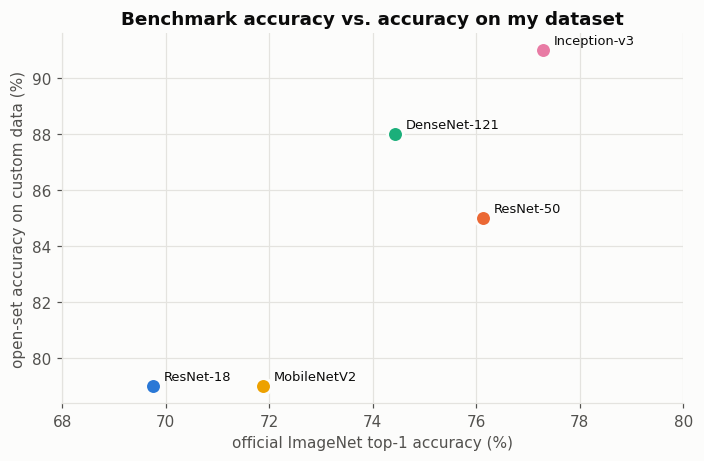

Spearman rank correlation: 0.87


In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4.3))
for name in MODEL_NAMES:
    xv, yv = results.loc[name, "ImageNet top-1 (%)"], 100 * results.loc[name, "Accuracy"]
    ax.scatter(xv, yv, s=110, color=COLOR_OF[name], edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.annotate(name, (xv, yv), textcoords="offset points", xytext=(7, 4), fontsize=8.5)
ax.set_xlabel("official ImageNet top-1 accuracy (%)"); ax.set_ylabel("open-set accuracy on custom data (%)")
ax.set_title("Benchmark accuracy vs. accuracy on my dataset")
ax.set_xlim(68, 80)
plt.tight_layout(); plt.show()
print("Spearman rank correlation:",
      round(results["ImageNet top-1 (%)"].rank().corr(results["Accuracy"].rank()), 2))

> **Observation.** The ImageNet benchmark predicts the ranking on my data quite well (Spearman ρ ≈ 0.87): the two strongest ImageNet models are the two strongest here, and the two weakest are the two weakest. The one swap — **DenseNet-121 slightly beats ResNet-50** (0.88 vs 0.85) — is a difference of only 3 images, well inside the confidence intervals, so it should not be over-interpreted. All models score *higher* than their ImageNet top-1, because our task is easier: 5 visually distinct classes instead of 1,000, and one class (laptop) accepts two ImageNet labels.

### 9.10 Detailed report for the best model

In [24]:
best = results["F1"].idxmax()
print(f"Best model by macro F1: {best}\n")
print(classification_report(raw_results[best]["labels"], preds[best]["open"],
                            labels=list(range(NUM_CLASSES)), target_names=list(CLASS_NAMES.values()),
                            zero_division=0, digits=3))

Best model by macro F1: Inception-v3

              precision    recall  f1-score   support

 grand_piano      1.000     0.950     0.974        20
      laptop      1.000     0.900     0.947        20
       pizza      1.000     0.750     0.857        20
    starfish      1.000     1.000     1.000        20
    umbrella      1.000     0.950     0.974        20

   micro avg      1.000     0.910     0.953       100
   macro avg      1.000     0.910     0.951       100
weighted avg      1.000     0.910     0.951       100



And a peek at *how confident* the models are — the top-3 ImageNet guesses of every model for one image:

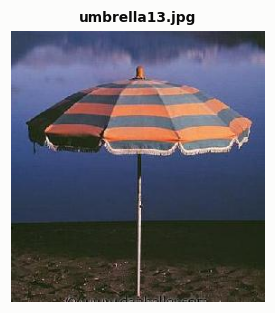

,#1,#2,#3
model,,,
ResNet-18,flagpole (34%),solar dish (21%),parachute (17%)
ResNet-50,umbrella (66%),parachute (14%),table lamp (8%)
DenseNet-121,flagpole (26%),parachute (18%),umbrella (8%)
MobileNetV2,umbrella (88%),parachute (3%),table lamp (2%)
Inception-v3,umbrella (96%),table lamp (0%),lampshade (0%)


In [25]:
demo_idx = name_to_idx["umbrella13.jpg"]
fig, ax = plt.subplots(figsize=(3.2, 3.2)); ax.imshow(raw_ds[demo_idx][0]); ax.axis("off")
ax.set_title("umbrella13.jpg", fontsize=9); plt.show()

rows = []
for name in MODEL_NAMES:
    probs = raw_results[name]["logits"][demo_idx].softmax(0)
    top = probs.topk(3)
    rows.append({"model": name, **{f"#{k+1}": f"{IMAGENET_CATEGORIES[i]} ({p:.0%})"
                                    for k, (p, i) in enumerate(zip(top.values.tolist(), top.indices.tolist()))}})
pd.DataFrame(rows).set_index("model")

> **Observation.** A single patio-style umbrella shows the spread of behaviour nicely: MobileNetV2, ResNet-50 and Inception-v3 answer *umbrella* (Inception with 96% confidence), while **ResNet-18 and DenseNet-121 choose *flagpole***, with *parachute* close behind. The weaker models are drawn to the **long vertical pole and the sky background**, whereas the stronger ones recognise the canopy shape as a whole. Notice also that four of the five models keep *parachute* in their top-3 — the same neighbour that shows up in the error table.

## 10. Experiment: do input requirements really matter?

The analysis asks us to consider **input requirements**. Rather than only arguing about it, I tested it on two models:

1. **Resolution mismatch** — evaluate ResNet-50 and Inception-v3 at both 224 px and 299 px
   (resize = crop / 0.875, the standard ratio).
2. **Missing normalisation** — evaluate ResNet-50 at the correct 224 px but with the `Normalize` step removed
   (a very common beginner mistake).

In [26]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def build_transform(crop, normalize=True):
    steps = [transforms.Resize(int(round(crop / 0.875))), transforms.CenterCrop(crop), transforms.ToTensor()]
    if normalize:
        steps.append(transforms.Normalize(MEAN, STD))
    return transforms.Compose(steps)

experiments = [("ResNet-50", 224, True, "native"), ("ResNet-50", 299, True, "larger than trained"),
               ("ResNet-50", 224, False, "no normalisation"),
               ("Inception-v3", 299, True, "native"), ("Inception-v3", 224, True, "smaller than trained")]

exp_rows, cached = [], {}
for name, crop, norm, note in experiments:
    if name not in cached:
        builder, weights = MODEL_SPECS[name]
        cached[name] = builder(weights=weights)
    res = run_inference(cached[name], make_loader(build_transform(crop, norm)))
    y_open, _ = open_set_predictions(res["logits"])
    _, _, f1 = macro_prf(res["labels"], y_open)
    exp_rows.append({"model": name, "input": f"{crop}×{crop}", "normalised": norm, "setting": note,
                     "Accuracy": accuracy_score(res["labels"], y_open), "F1": f1,
                     "Closed Acc": accuracy_score(res["labels"], closed_set_predictions(res["logits"]))})
del cached
input_exp = pd.DataFrame(exp_rows)
input_exp.round(3)

,model,input,normalised,setting,Accuracy,F1,Closed Acc
0,ResNet-50,224×224,True,native,0.85,0.915,1.00
1,ResNet-50,299×299,True,larger than trained,0.80,0.884,1.00
2,ResNet-50,224×224,False,no normalisation,0.69,0.739,0.97
3,Inception-v3,299×299,True,native,0.91,0.951,1.00
4,Inception-v3,224×224,True,smaller than trained,0.86,0.918,1.00


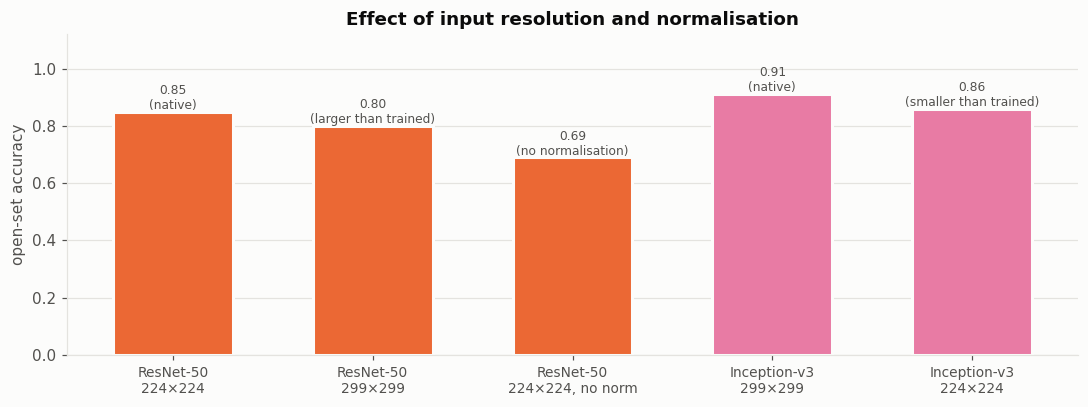

In [27]:
fig, ax = plt.subplots(figsize=(10, 3.8))
labels = [f"{r.model}\n{r.input}{'' if r.normalised else ', no norm'}" for r in input_exp.itertuples()]
colors = [COLOR_OF[m] for m in input_exp.model]
bars = ax.bar(range(len(input_exp)), input_exp.Accuracy, color=colors, width=0.6, edgecolor=SURFACE, linewidth=2)
for b, r in zip(bars, input_exp.itertuples()):
    ax.text(b.get_x() + b.get_width() / 2, r.Accuracy + 0.01, f"{r.Accuracy:.2f}\n({r.setting})",
            ha="center", fontsize=8, color=INK_2)
ax.set_xticks(range(len(input_exp)), labels, fontsize=9)
ax.set_ylim(0, 1.12); ax.set_ylabel("open-set accuracy"); ax.grid(axis="x", visible=False)
ax.set_title("Effect of input resolution and normalisation")
plt.tight_layout(); plt.show()

> **Observation.** Input requirements clearly matter:
> * **Wrong resolution costs ~5 percentage points in both directions.** ResNet-50 drops from 0.85 → 0.80 when fed 299 px, and Inception-v3 drops from 0.91 → 0.86 when fed 224 px. A CNN's filters are tuned to the *object scale* seen in training; changing the resolution makes objects appear larger or smaller than the network expects.
> * **Skipping normalisation is worse: ResNet-50 falls from 0.85 → 0.69** (a 16-point drop). Without `Normalize`, inputs lie in [0, 1] instead of roughly [−2, +2.6], so every activation after the first layer is shifted and BatchNorm's stored statistics no longer match.
> * Interesting detail: Inception-v3 at 224 px (0.86) is still as good as ResNet-50 at its native 224 px (0.85), so its advantage is **not only** its bigger input — the architecture itself contributes.

## 11. Analysis

### 11.1 Summary of the results

| Rank | Model | Open-set accuracy (95% CI) | Macro F1 | Top-5 | Closed-set | Params | GFLOPs |
|:---:|---|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | **Inception-v3** | **0.91** (0.85–0.96) | **0.951** | 1.00 | 1.00 | 27.2 M | 5.71 |
| 2 | DenseNet-121 | 0.88 (0.81–0.94) | 0.932 | 0.99 | 1.00 | 8.0 M | 2.83 |
| 3 | ResNet-50 | 0.85 (0.77–0.91) | 0.915 | 0.99 | 1.00 | 25.6 M | 4.09 |
| 4 | MobileNetV2 | 0.79 (0.70–0.87) | 0.879 | 0.97 | 1.00 | 3.5 M | 0.30 |
| 5 | ResNet-18 | 0.79 (0.70–0.87) | 0.871 | 0.96 | 1.00 | 11.7 M | 1.81 |

All five models transfer well to a dataset they were never trained on — without a single step of training.
Inception-v3 is the most accurate, DenseNet-121 gives the best accuracy for its size, and MobileNetV2 gives the best
accuracy for its compute. The rest of this section explains *why* the numbers differ.

### 11.2 Model architecture

* **Inception-v3 (best, 0.91).** Each Inception module runs several convolution branches in parallel (1×1, factorised 3×3
  and 5×5-equivalent, pooling) and concatenates them, so every layer looks at the image at **several scales at once**.
  That fits our data well: a laptop must be recognised both from its overall shape (screen + base) and from local texture
  (keys), and a patio umbrella from its whole canopy rather than just its pole. Inception-v3 fixed most of the laptop
  errors that every other model made (18/20 vs 13–14/20).
* **DenseNet-121 (0.88).** Each layer receives the feature maps of *all* earlier layers in its block. This **feature reuse**
  means low-level colour/texture features and high-level shape features are both available to the classifier. It had the
  best pizza score (17/20) — a class where texture alone is misleading (trifle, potpie) and shape must be combined with it.
* **ResNet-50 vs ResNet-18 (0.85 vs 0.79).** Same design idea (residual connections), different depth: 50 vs 18 layers,
  with bottleneck blocks. The deeper network builds more abstract, object-level features; ResNet-18's errors are typical of
  a shallower network relying on **colour and texture** — a red, round, cheesy object became *trifle*, *Dutch oven*,
  *waffle iron* (it recognised only 11/20 pizzas).
* **MobileNetV2 (0.79).** Built from **depthwise-separable convolutions** and inverted residual blocks to run on phones.
  These cut the computation by an order of magnitude, but also the capacity to model subtle distinctions. Its errors show
  **background reliance**: it was the only model to miss starfish, labelling them *coral reef*, *sea slug*, *electric ray*
  and *eft* — the underwater background and texture won over the star shape.

### 11.3 Model complexity

Complexity helps, but with strongly diminishing returns and not in a straight line:

* Within one family, more capacity helps (ResNet-18 → ResNet-50: +6 points for 2.3× compute).
* Across families, **architecture beats raw size**: DenseNet-121 has *less than a third* of ResNet-50's parameters and
  30% less compute, yet scored higher; MobileNetV2 equals ResNet-18 with 1/6 of the compute.
* The most complex model (Inception-v3) is the most accurate, but it costs ~19× the compute of MobileNetV2 and was the
  slowest per image — several times slower than MobileNetV2 (see the `ms/img` column; exact timings vary between runs and machines).
* Complexity also shows up in **confidence**: ResNet-50 put the most probability on the true class (0.78) even though
  Inception-v3 was more accurate. Inception-v3 was trained with *label smoothing*, which intentionally prevents over-confident
  outputs — a reminder that a model's probabilities are shaped by its training recipe, not just its architecture.

### 11.4 Input requirements

The experiment in Section 10 turned this from theory into evidence:

* Each model has a **native resolution** (224 px for four models, 299 px for Inception-v3). Using the wrong one cost about
  **5 points** in either direction, because the filters are tuned to the object scale seen during training.
* **Normalisation with ImageNet mean/std is not optional**: removing it dropped ResNet-50 from 0.85 to 0.69.
* Our Caltech-101 photos are small (shorter side ≈ 190–300 px). Inception-v3 must **upsample every image** to 342 px,
  which adds no new detail — yet it still won, and even at 224 px it matched ResNet-50. So its advantage comes from the
  **architecture**, with the larger input helping on top of that.
* Using `weights.transforms()` (instead of hand-written transforms) guaranteed every model got exactly its required input.
  Also necessary: converting the one grayscale image to 3-channel RGB inside the `Dataset`.

### 11.5 Suitability for the selected dataset

* **The classes suit ImageNet models very well.** Every class exists in ImageNet, and they are visually distinct from each
  other — hence 100% closed-set accuracy, precision of 1.00 and near-perfect top-5. The models *see* the objects correctly.
* **The difficulty comes from ImageNet's fine-grained label space.** With 1,000 classes, many have close neighbours:
  laptop vs *notebook / hand-held computer / desktop computer / space bar*, pizza vs *potpie / trifle / meat loaf*,
  patio umbrella vs *parachute / yurt / patio*. Open-set errors are almost all "near misses" of this kind.
* **Domain shift.** Caltech-101 was collected around 2003: bulky 1990s laptops, low-resolution JPEGs, many studio
  product shots on white backgrounds. ImageNet's photos of the same classes differ in era and style, which hurts most on
  laptop — the class whose appearance changed the most over time.
* **Class-level suitability.** *Grand piano* and *starfish* have unmistakable silhouettes → near-perfect for every model.
  *Pizza* is a texture-heavy food with many look-alike ImageNet foods. *Umbrella* in ImageNet is mostly the hand-held rain
  umbrella, whereas several of ours are patio/beach umbrellas whose context (sky, sand, garden) pulls predictions toward
  outdoor classes.

### 11.6 How confident can we be in the ranking?

With 100 test images, one image = 1 percentage point, and the bootstrap 95% intervals are about ±7 points wide.
The intervals of Inception-v3 (0.85–0.96) and ResNet-18/MobileNetV2 (0.70–0.87) barely overlap, so "Inception-v3 is better
than the two small models" is reasonably supported. The differences among **Inception-v3, DenseNet-121 and ResNet-50
(3 images apart each) are within noise**; a larger test set (or a paired test such as McNemar's) would be needed to
separate them. The fact that the ranking agrees with the official ImageNet ranking (ρ ≈ 0.87) gives extra confidence
that the overall ordering is real.

## 12. Conclusion

In this activity I built a custom 5-class image dataset (grand piano, laptop, pizza, starfish, umbrella — 100 real photos
curated from Caltech-101), loaded it with my own PyTorch `Dataset` class and `DataLoader`s, and evaluated five
ImageNet-pretrained models from `torchvision.models` purely by inference.

**Key findings**

1. **Pretrained models transfer well without training.** Open-set (1,000-way) accuracy ranged from 0.79 to 0.91, top-5
   accuracy from 0.96 to 1.00, and when the choice was restricted to my five classes every model scored **100%**.
2. **Inception-v3 performed best** (accuracy 0.91, macro F1 0.951), followed by DenseNet-121 (0.88 / 0.932) and
   ResNet-50 (0.85 / 0.915); ResNet-18 and MobileNetV2 tied last (0.79). This matches the models' ImageNet ranking closely.
3. **Architecture matters more than size.** DenseNet-121 beat ResNet-50 with a third of the parameters, and MobileNetV2
   matched ResNet-18 with 1/6 of the compute — the best choices for accuracy-per-parameter and accuracy-per-FLOP respectively.
4. **Errors were "near misses" in ImageNet's label space**, not failures to see the object: laptops became *hand-held
   computer* or *space bar*, pizzas became *trifle* or *potpie*, patio umbrellas became *parachute* or *patio*. Precision
   was 1.00 for every model because no model ever confused two of my classes with each other.
5. **Input requirements are critical.** Feeding the wrong resolution cost ~5 points and skipping ImageNet normalisation
   cost 16 points — always use the preprocessing that matches the weights (`weights.transforms()`).

**Which model would I choose?** For the highest accuracy: **Inception-v3**. For the best balance of accuracy and cost:
**DenseNet-121**. For a phone or other low-power device: **MobileNetV2**.

**Limitations and next steps.** 100 images give confidence intervals of about ±7 points, so the top three models cannot be
separated with certainty. Natural next steps are (1) collecting more images per class, (2) **fine-tuning** the final layer
of each model on my five classes, which should remove the "other" errors entirely, and (3) comparing newer architectures
such as EfficientNet or Vision Transformers.

## References

* He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image Recognition.* CVPR.
* Huang, G., Liu, Z., van der Maaten, L., & Weinberger, K. Q. (2017). *Densely Connected Convolutional Networks.* CVPR.
* Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks.* CVPR.
* Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J., & Wojna, Z. (2016). *Rethinking the Inception Architecture for Computer Vision.* CVPR.
* Fei-Fei, L., Fergus, R., & Perona, P. (2004). *Learning Generative Visual Models from Few Training Examples* (Caltech-101). CVPR Workshop.
* Deng, J. et al. (2009). *ImageNet: A Large-Scale Hierarchical Image Database.* CVPR.
* PyTorch / torchvision documentation — *Models and pre-trained weights*: https://docs.pytorch.org/vision/stable/models.html